In [1]:
"""Flux-dev Prompt-based Image Editing

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import FluxPipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev", torch_dtype=torch.bfloat16
).to("cuda")

/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]`torch_dtype` is deprecated! Use `dtype` instead!
You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 12.96it/s]


Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:53<00:00,  1.90s/it]


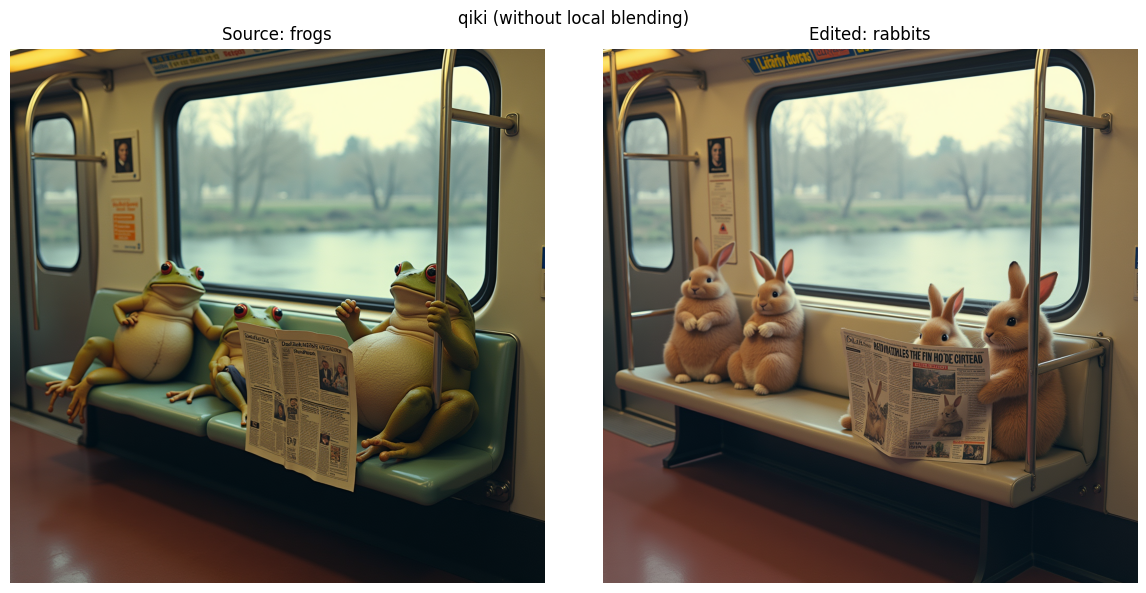

In [3]:
# Replace (qiki) - without local blending

prompts = [
    'A photograph of the inside of a subway train. There are frogs sitting on the seats. One of them is reading a newspaper. The window shows the river in the background.', 
    'A photograph of the inside of a subway train. There are rabbits sitting on the seats. One of them is reading a newspaper. The window shows the river in the background.'
]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: frogs")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: rabbits")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


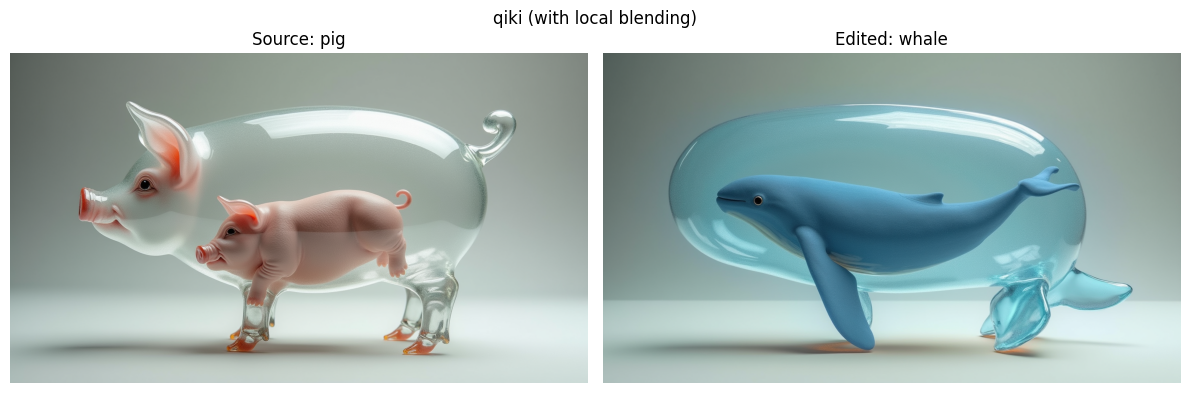

In [3]:
# Replace (qiki) - with local blending

prompts = [
    "translucent pig, inside is a smaller pig.",
    "translucent whale, inside is a smaller whale."
]
height, width = 768, 1344
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[["pig,", "pig."], ["whale,", "whale."]],
    local_blend_threshold=0.3,
    aggregate_blocks=TOP5_BLOCKS["flux-dev"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(12341234), torch.Generator().manual_seed(12341234)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title("Source: pig")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: whale")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.96s/it]


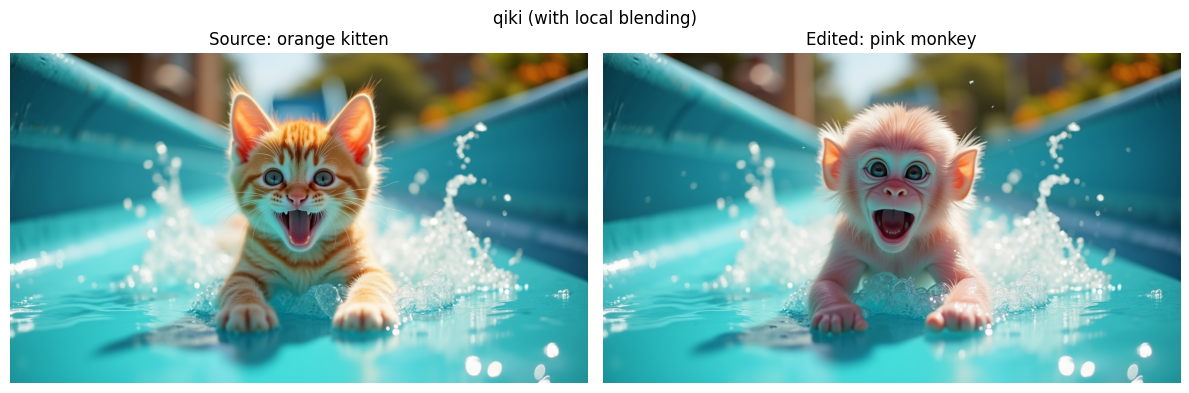

In [4]:
# Replace (qiki) - with local blending

prompts = [
    "cute orange kitten sliding down an aqua slide. happy excited. 16mm lens in front. we see his excitement and scared in the eye. vibrant colors. water splashing on the lens",
    "cute pink monkey sliding down an aqua slide. happy excited. 16mm lens in front. we see his excitement and scared in the eye. vibrant colors. water splashing on the lens",
]
height, width = 768, 1344
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=["orange kitten", "pink monkey"],
    local_blend_threshold=0.3,
    aggregate_blocks=TOP5_BLOCKS["flux-dev"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title("Source: orange kitten")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: pink monkey")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.96s/it]


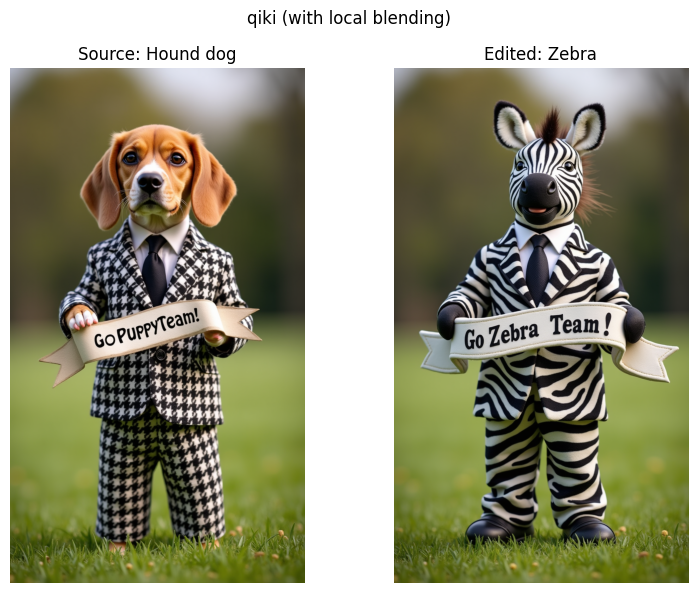

In [5]:
# Replace (qiki) - with local blending

prompts = [
    'A 4K DSLR image of a Hound dog dressed in a finely tailored houndstooth check suit with bold, oversized patterns standing on a perfectly manicured grassy field holding a beautifully crafted banner that says "Go Puppy Team!"',
    'A 4K DSLR image of a Zebra dressed in a finely tailored zebra-striped suit with bold, oversized patterns standing on a perfectly manicured grassy field holding a beautifully crafted banner that says "Go Zebra Team!"'
]
height, width = 1344, 768
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[['Hound dog', 'houndstooth check suit', '"Go Puppy Team!"'], ['Zebra', 'zebra-striped suit', '"Go Zebra Team!"']],
    local_blend_threshold=0.15,
    aggregate_blocks=TOP5_BLOCKS["flux-dev"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(12341234), torch.Generator().manual_seed(12341234)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: Hound dog")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: Zebra")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Token indices sequence length is longer than the specified maximum sequence length for this model (93 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['end. the two animals share a same speech bubble above them saying " flux!"', 'end. the two animals share a same speech bubble above them saying " attention!"']


Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.96s/it]


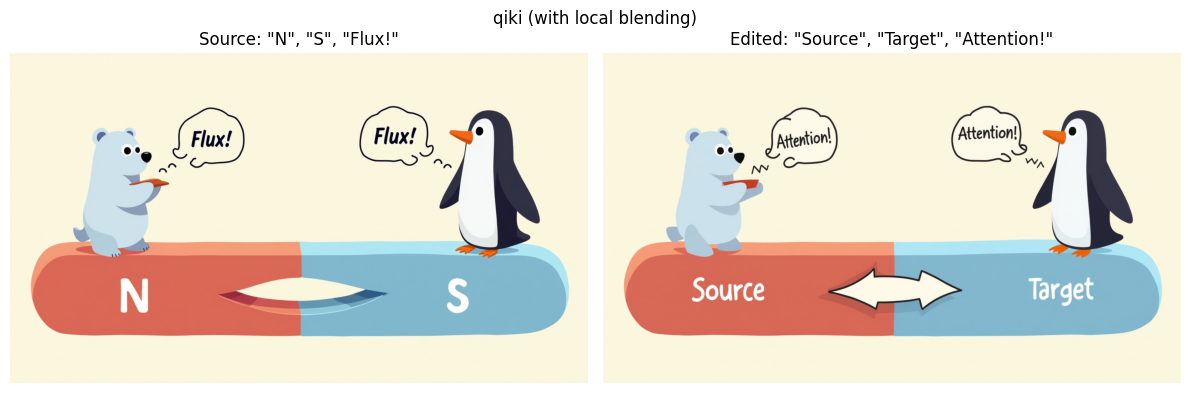

In [6]:
# Replace (qiki) - with local blending

prompts = [
    'A cartoon-style illustration of a horizontal bar, with the left side labeled "N" and colored red, and the right side labeled "S" and colored blue. A polar bear holds the red side, and a penguin holds the blue side. A smooth, convex arrow-shaped black line flows outward from the leftmost end and curve gently toward the rightmost end. The two animals share a same speech bubble above them saying "Flux!"',
    'A cartoon-style illustration of a horizontal bar, with the left side labeled "Source" and colored red, and the right side labeled "Target" and colored blue. A polar bear holds the red side, and a penguin holds the blue side. A smooth, convex arrow-shaped black line flows outward from the leftmost end and curve gently toward the rightmost end. The two animals share a same speech bubble above them saying "Attention!"'
]

height, width = 768, 1344 
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[['"N"', '"S"', '"Flux!"'], ['"Source"', '"Target"', '"Attention!"']],
    local_blend_threshold=0.15,
    aggregate_blocks=TOP5_BLOCKS["flux-dev"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(24523487), torch.Generator().manual_seed(24523487)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title('Source: "N", "S", "Flux!"')
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title('Edited: "Source", "Target", "Attention!"')
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.96s/it]


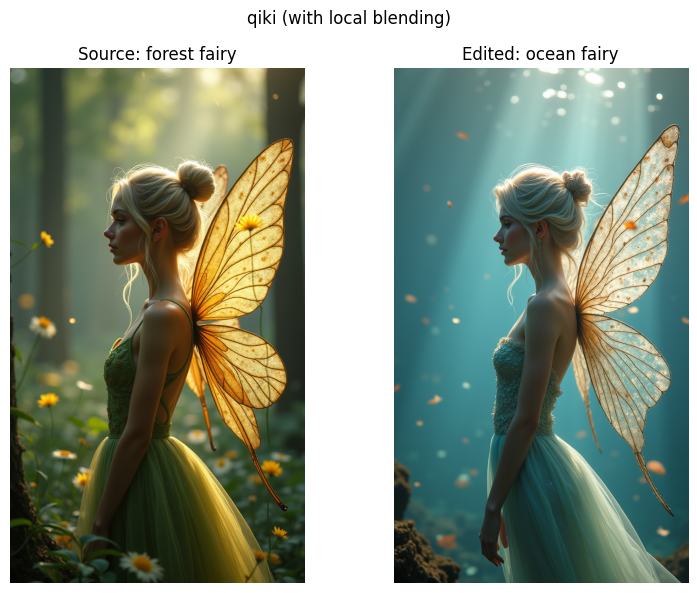

In [7]:
# Replace (qiki) - with local blending

prompts = [
    'An 8K DSLR image of a beautiful and lively forest fairy with transparent shimmering wings that resemble glossy cellophane that reflects her surrondings. The aesthetic is enchanting with a magical and otherworldly charm.',
    'An 8K DSLR image of a beautiful and lively ocean fairy with transparent watery wings that resemble glossy cellophane that reflects her surrondings. The aesthetic is enchanting with a magical and otherworldly charm.',
]

height, width = 1344, 768 
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words=[['forest fairy', 'transparent shimmering wings'], ['ocean fairy', 'transparent watery wings']],
    local_blend_threshold=0.15,
    aggregate_blocks=TOP5_BLOCKS["flux-dev"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(12341234), torch.Generator().manual_seed(12341234)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: forest fairy")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: ocean fairy")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


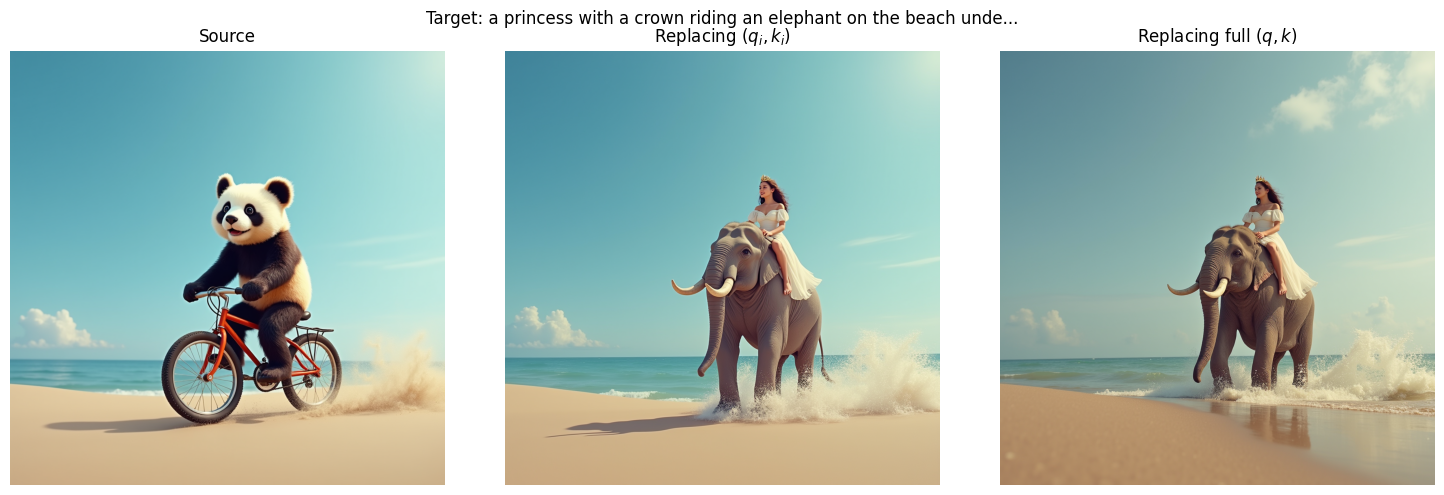

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


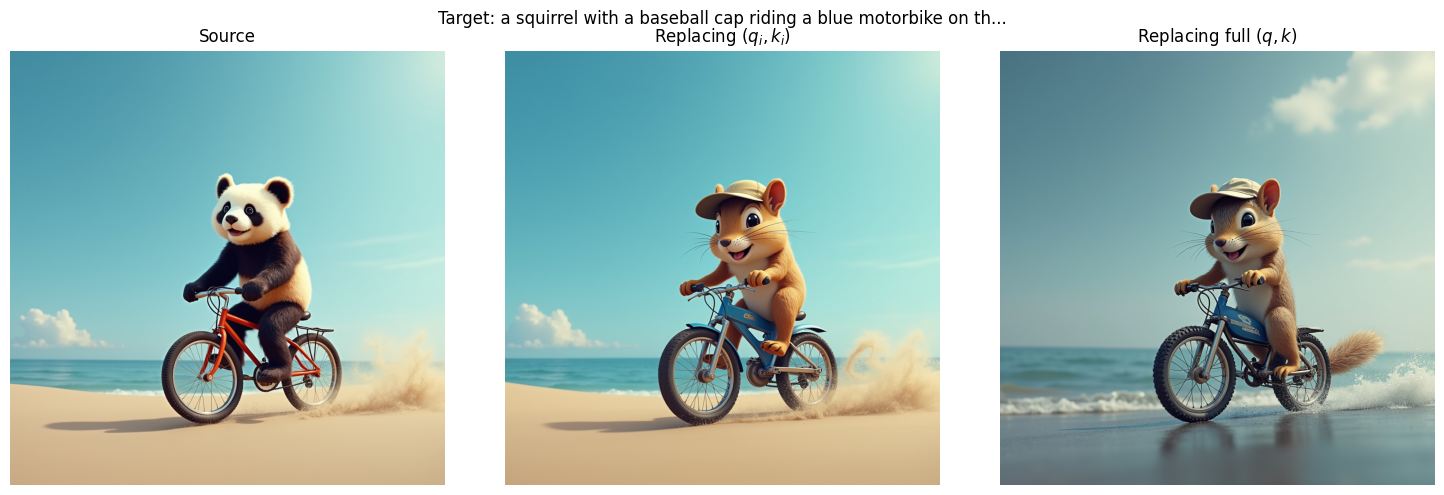

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:53<00:00,  1.93s/it]


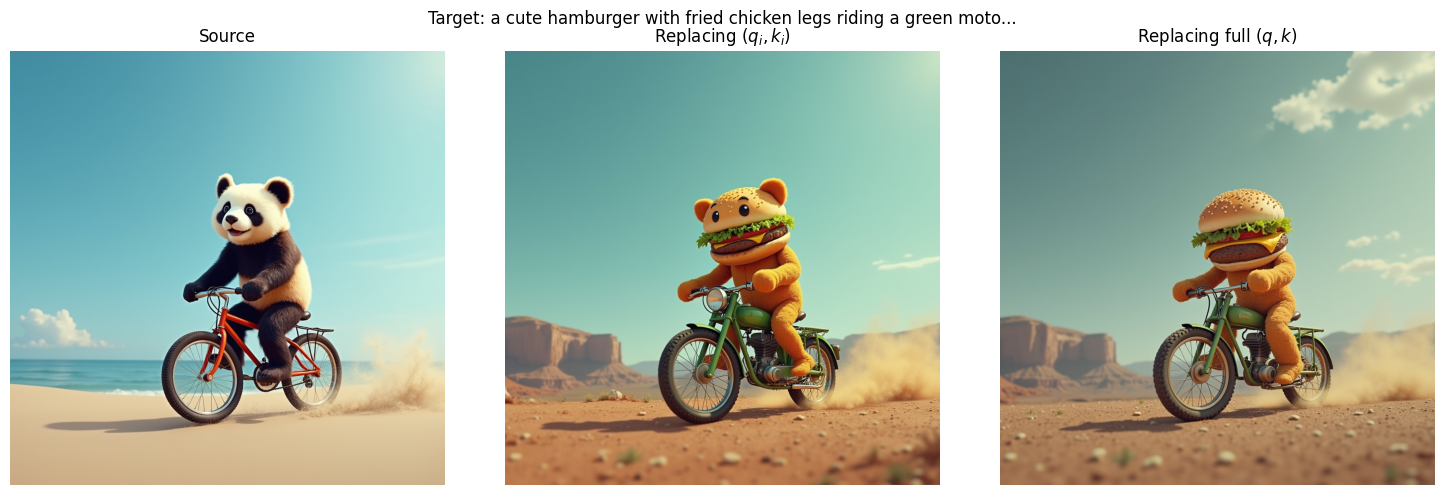

In [8]:
# qiki vs qk comparison (no local blending)
# Three different prompt pairs showing the difference between replacing (q_i, k_i) vs full (q, k)

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]
seed = 864

prompt_pairs = [
    ("a panda riding a bicycle on the beach under blue sky", 
     "a princess with a crown riding an elephant on the beach under blue sky"),
    ("a panda riding a bicycle on the beach under blue sky", 
     "a squirrel with a baseball cap riding a blue motorbike on the beach under blue sky"),
    ("a panda riding a bicycle on the beach under blue sky", 
     "a cute hamburger with fried chicken legs riding a green motorbike in the grand canyon under blue sky"),
]

for idx, (src_prompt, tgt_prompt) in enumerate(prompt_pairs):
    prompts = [src_prompt, tgt_prompt]
    results = {"source": None, "qiki": None, "qk": None}
    
    for method in ["qiki", "qk"]:
        controller = create_qkv_controller(
            pipeline_type="flux",
            prompts=prompts,
            num_inference_steps=28,
            tokenizer=tokenizers,
            device=pipe.device,
            dtype=pipe.dtype,
            method=method,
            t5_max_seq_len=512,
            height=height,
            width=width,
        )
        register_qkv_control(pipe, controller)
        imgs = pipe(
            prompt=prompts,
            num_inference_steps=28,
            guidance_scale=3.5,
            height=height,
            width=width,
            max_sequence_length=512,
            generator=[torch.Generator().manual_seed(seed), torch.Generator().manual_seed(seed)],
            callback_on_step_end=p2p_callback,
            callback_on_step_end_tensor_inputs=["latents"],
        ).images
        controller.reset()
        
        if results["source"] is None:
            results["source"] = imgs[0]
        results[method] = imgs[1]
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(results["source"])
    ax[0].set_title("Source")
    ax[0].axis("off")
    ax[1].imshow(results["qiki"])
    ax[1].set_title("Replacing $(q_i, k_i)$")
    ax[1].axis("off")
    ax[2].imshow(results["qk"])
    ax[2].set_title("Replacing full $(q, k)$")
    ax[2].axis("off")
    plt.suptitle(f"Target: {tgt_prompt[:60]}...")
    plt.tight_layout()
    plt.show()

Registered 57 attention processors (SDPA: True).


100%|██████████| 28/28 [00:54<00:00,  1.93s/it]


Registered 57 attention processors (SDPA: False).


100%|██████████| 28/28 [01:14<00:00,  2.67s/it]


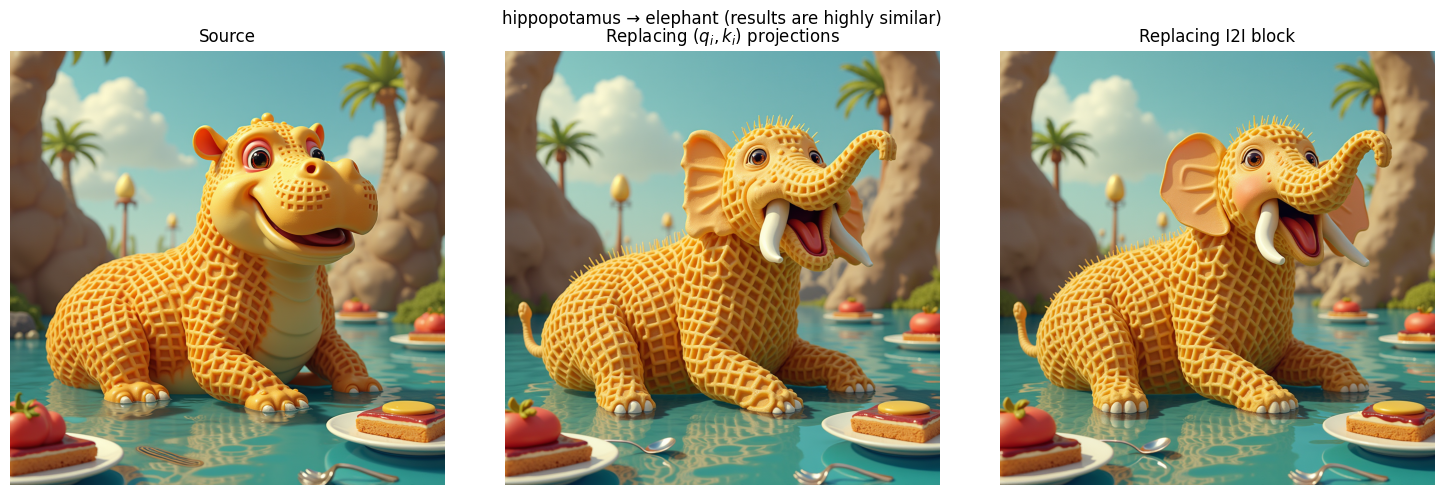

In [9]:
# qiki vs I2I comparison (no local blending)
# Shows that replacing (q_i, k_i) projections and replacing I2I attention block produce similar results

prompts = [
    "A whimsical scene featuring a playful hybrid creature: a hippopotamus with golden, crispy waffle-textured skin, lounging in a surreal habitat blending water and breakfast elements like giant utensils and plates.",
    "A whimsical scene featuring a playful hybrid creature: an elephant with golden, crispy waffle-textured skin, lounging in a surreal habitat blending water and breakfast elements like giant utensils and plates."
]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]
seed = 1234

results = {"source": None, "qiki": None, "I2I": None}

for method in ["qiki", "I2I"]:
    controller = create_qkv_controller(
        pipeline_type="flux",
        prompts=prompts,
        num_inference_steps=28,
        tokenizer=tokenizers,
        device=pipe.device,
        dtype=pipe.dtype,
        method=method,
        t5_max_seq_len=512,
        height=height,
        width=width,
    )
    register_qkv_control(pipe, controller)
    imgs = pipe(
        prompt=prompts,
        num_inference_steps=28,
        guidance_scale=3.5,
        height=height,
        width=width,
        max_sequence_length=512,
        generator=[torch.Generator().manual_seed(seed), torch.Generator().manual_seed(seed)],
        callback_on_step_end=p2p_callback,
        callback_on_step_end_tensor_inputs=["latents"],
    ).images
    controller.reset()
    
    if results["source"] is None:
        results["source"] = imgs[0]
    results[method] = imgs[1]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(results["source"])
ax[0].set_title("Source")
ax[0].axis("off")
ax[1].imshow(results["qiki"])
ax[1].set_title("Replacing $(q_i, k_i)$ projections")
ax[1].axis("off")
ax[2].imshow(results["I2I"])
ax[2].set_title("Replacing I2I block")
ax[2].axis("off")
plt.suptitle("hippopotamus → elephant (results are highly similar)")
plt.tight_layout()

In [10]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
